In [1]:
# Importando bibliotecas essenciais
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Carregando os nomes das colunas do arquivo de features
data_path = '../../data/raw/UNSW-NB15'
try:
    df_features = pd.read_csv(os.path.join(data_path, 'UNSW-NB15_features.csv'), encoding='latin-1')
    col_names = df_features['Name'].tolist()
except FileNotFoundError:
    print("Arquivo 'UNSW-NB15_features.csv' não encontrado. Definindo nomes das colunas manualmente.")
    # Nomes retirados dos artigos e da estrutura do dataset
    col_names = ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label']


# Carregando os datasets de treino e teste
# O 'id' não é uma feature, então o ignoramos, mas vamos mantê-lo por enquanto para inspeção
train_path = os.path.join(data_path, 'UNSW_NB15_training-set.csv')
test_path = os.path.join(data_path, 'UNSW_NB15_testing-set.csv')

# Os CSVs originais não têm cabeçalho, então definimos os nomes manualmente.
# O arquivo de treino parece ter uma coluna extra 'id' no início.
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


print("Formato do dataset de treino:", df_train.shape)
print("Formato do dataset de teste:", df_test.shape)

Arquivo 'UNSW-NB15_features.csv' não encontrado. Definindo nomes das colunas manualmente.
Formato do dataset de treino: (175341, 45)
Formato do dataset de teste: (82332, 45)


In [3]:
print("--- Primeiras 5 linhas do Dataset de Treino ---")
display(df_train.head())

print("\n--- Informações do Dataset de Treino ---")
df_train.info()

print("\n\n--- Primeiras 5 linhas do Dataset de Teste ---")
display(df_test.head())

print("\n--- Informações do Dataset de Teste ---")
df_test.info()

--- Primeiras 5 linhas do Dataset de Treino ---


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0



--- Informações do Dataset de Treino ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss    

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0



--- Informações do Dataset de Teste ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-

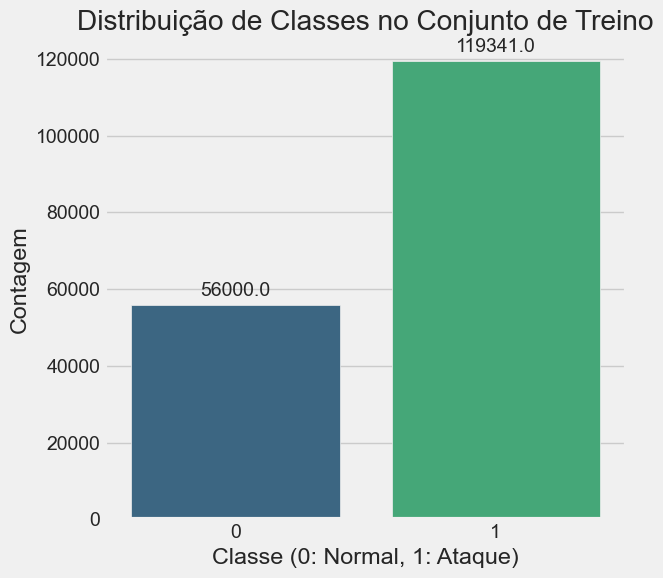

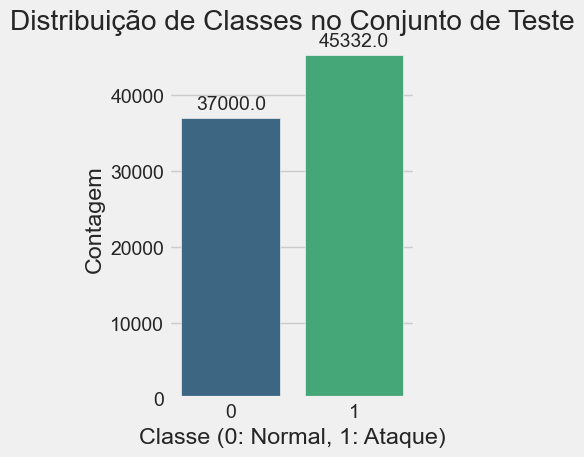

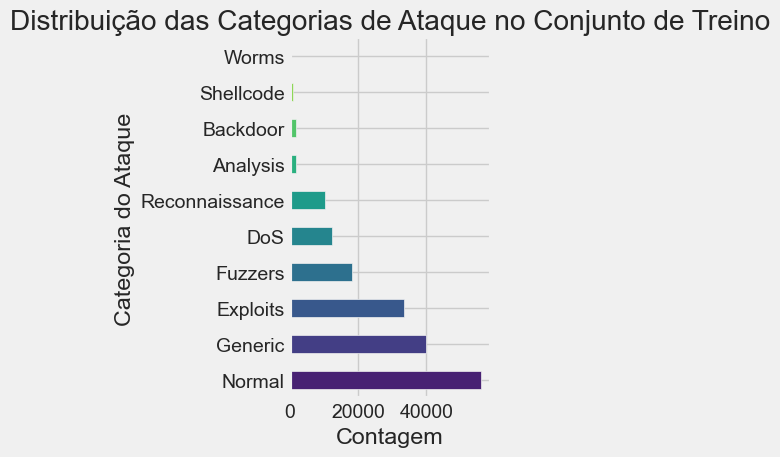

--- Análise das Features Categóricas ---


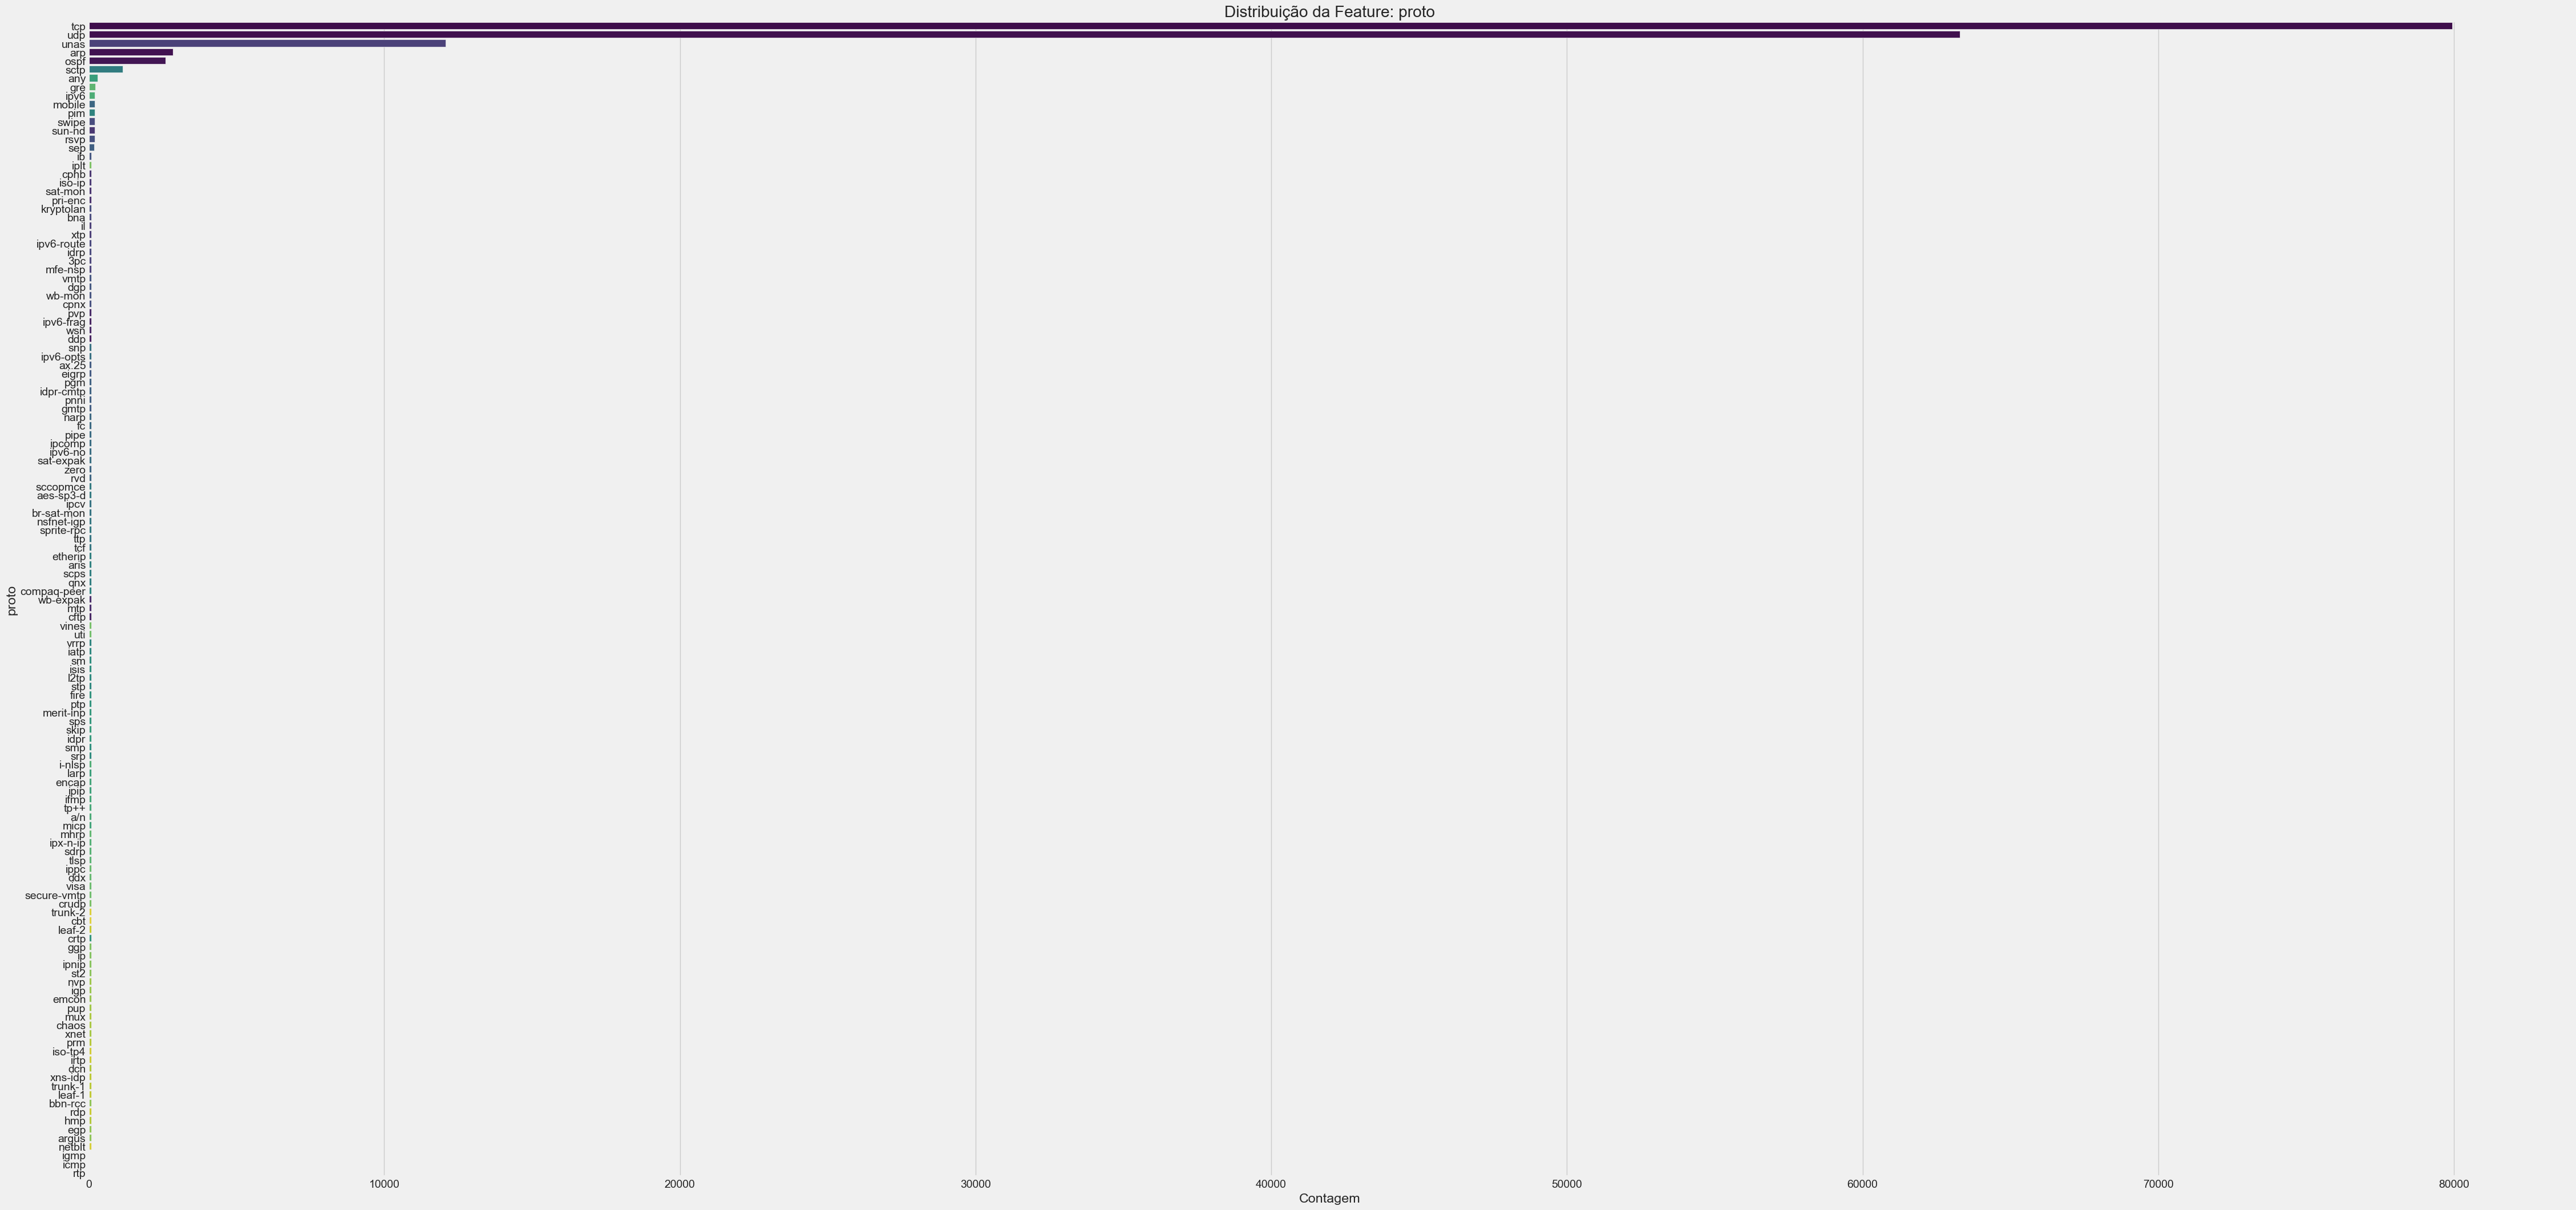

Valores únicos em 'proto': 133
------------------------------


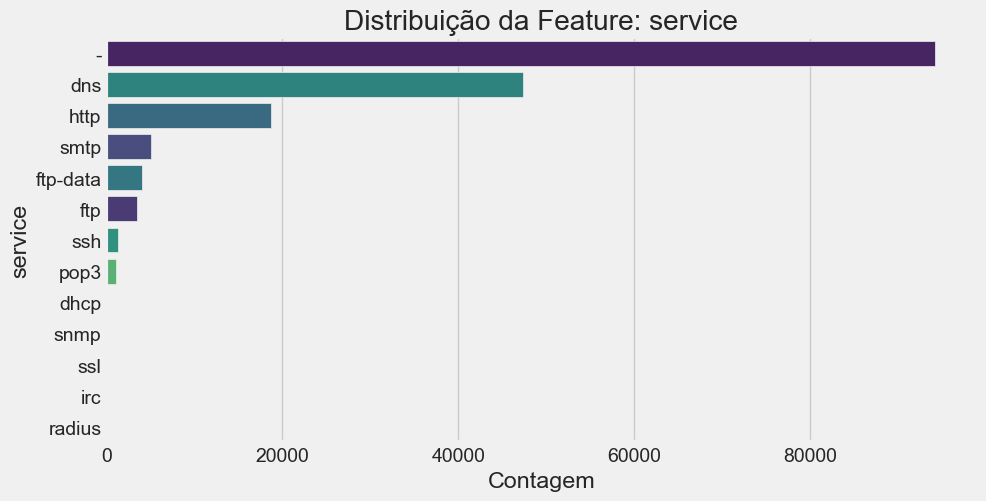

Valores únicos em 'service': 13
------------------------------


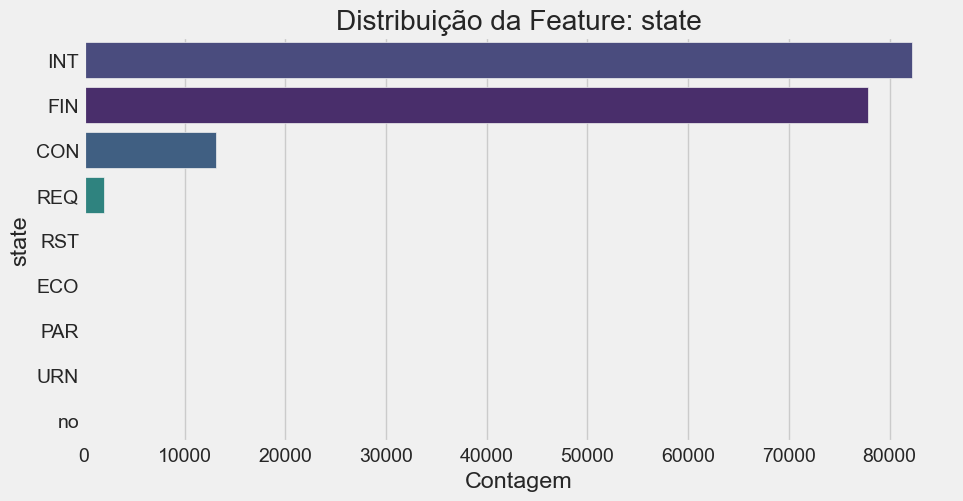

Valores únicos em 'state': 9
------------------------------
Proporção de classes no treino:
label
1    68.062233
0    31.937767
Name: proportion, dtype: float64


In [4]:
# Verificando a distribuição da variável alvo binária (label)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
ax = sns.countplot(x='label', data=df_train, palette='viridis', hue='label', legend=False)
plt.title('Distribuição de Classes no Conjunto de Treino')
plt.xlabel('Classe (0: Normal, 1: Ataque)')
plt.ylabel('Contagem')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.tight_layout()
plt.show()

plt.subplot(1, 2, 1)
ax = sns.countplot(x='label', data=df_test, palette='viridis', hue='label', legend=False)
plt.title('Distribuição de Classes no Conjunto de Teste')
plt.xlabel('Classe (0: Normal, 1: Ataque)')
plt.ylabel('Contagem')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.tight_layout()
plt.show()

# Verificando a distribuição das categorias de ataque (attack_cat)
plt.subplot(1, 2, 2)
plt.title('Distribuição das Categorias de Ataque no Conjunto de Treino')
df_train['attack_cat'].value_counts().plot(kind='barh', color=sns.color_palette("viridis", len(df_train['attack_cat'].unique())))
plt.xlabel('Contagem')
plt.ylabel('Categoria do Ataque')

plt.tight_layout()
plt.show()

# Identificando as colunas categóricas
categorical_cols = ['proto', 'service', 'state']

print("--- Análise das Features Categóricas ---")
for col in categorical_cols:
    if col == 'proto':
        plt.figure(figsize=(50, 25))
        sns.countplot(y=col, data=df_train, order=df_train[col].value_counts().index, palette='viridis', hue=col, legend=False)
        plt.title(f'Distribuição da Feature: {col}')
        plt.xlabel('Contagem')
        plt.ylabel(col)
        plt.show()
        print(f"Valores únicos em '{col}': {df_train[col].nunique()}")
        print("-" * 30)
    else:
        plt.figure(figsize=(10, 5))
        sns.countplot(y=col, data=df_train, order=df_train[col].value_counts().index, palette='viridis', hue=col, legend=False)
        plt.title(f'Distribuição da Feature: {col}')
        plt.xlabel('Contagem')
        plt.ylabel(col)
        plt.show()
        print(f"Valores únicos em '{col}': {df_train[col].nunique()}")
        print("-" * 30)

# Proporções
print("Proporção de classes no treino:")
print(df_train['label'].value_counts(normalize=True) * 100)

--- Estatísticas Descritivas (Features Numéricas) ---


,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,6.712056e+05,4.953000,6.948010,985.976864,88.216296,4.976254e+03,604.353826,116.257339,9.692504e+08,9.688770e+08,115.013625,0.041396,0.021020,0.020375,136.751769,124.173382,0.105982,2.144292e+03,9.306437,1.304179,6.193936,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,2.421312e+06,66.005059,52.732999,7242.245841,987.093195,4.496585e+04,4061.043281,127.001024,1.355264e+09,1.354000e+09,126.886530,0.079354,0.043400,0.040506,204.677360,258.317056,0.776911,5.420797e+04,10.704331,0.954406,8.052476,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,28.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,0.000000e+00,0.000000,0.000000,0.008000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,0.000000e+00,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,1.447023e+03,0.000000,0.000000,0.279733,0.006000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,73.000000,44.000000,0.000000,0.000000e+00,5.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,2.784487e+04,3.000000,2.000000,55.156896,51.053000,2.513295e+03,114.990625,255.000000,1.916651e+09,1.913675e+09,255.000000,0.065481,0.023268,0.038906,100.000000,89.000000,0.000000,0.000000e+00,12.000000,2.000000,7.000000,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,2.242273e+07,4803.000000,5484.000000,84371.496000,56716.824000,1.460480e+06,289388.269700,255.000000,4.294959e+09,4.294882e+09,255.000000,2.518893,2.100352,1.520884,1504.000000,1458.000000,172.000000,6.558056e+06,63.000000,6.000000,51.000000,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


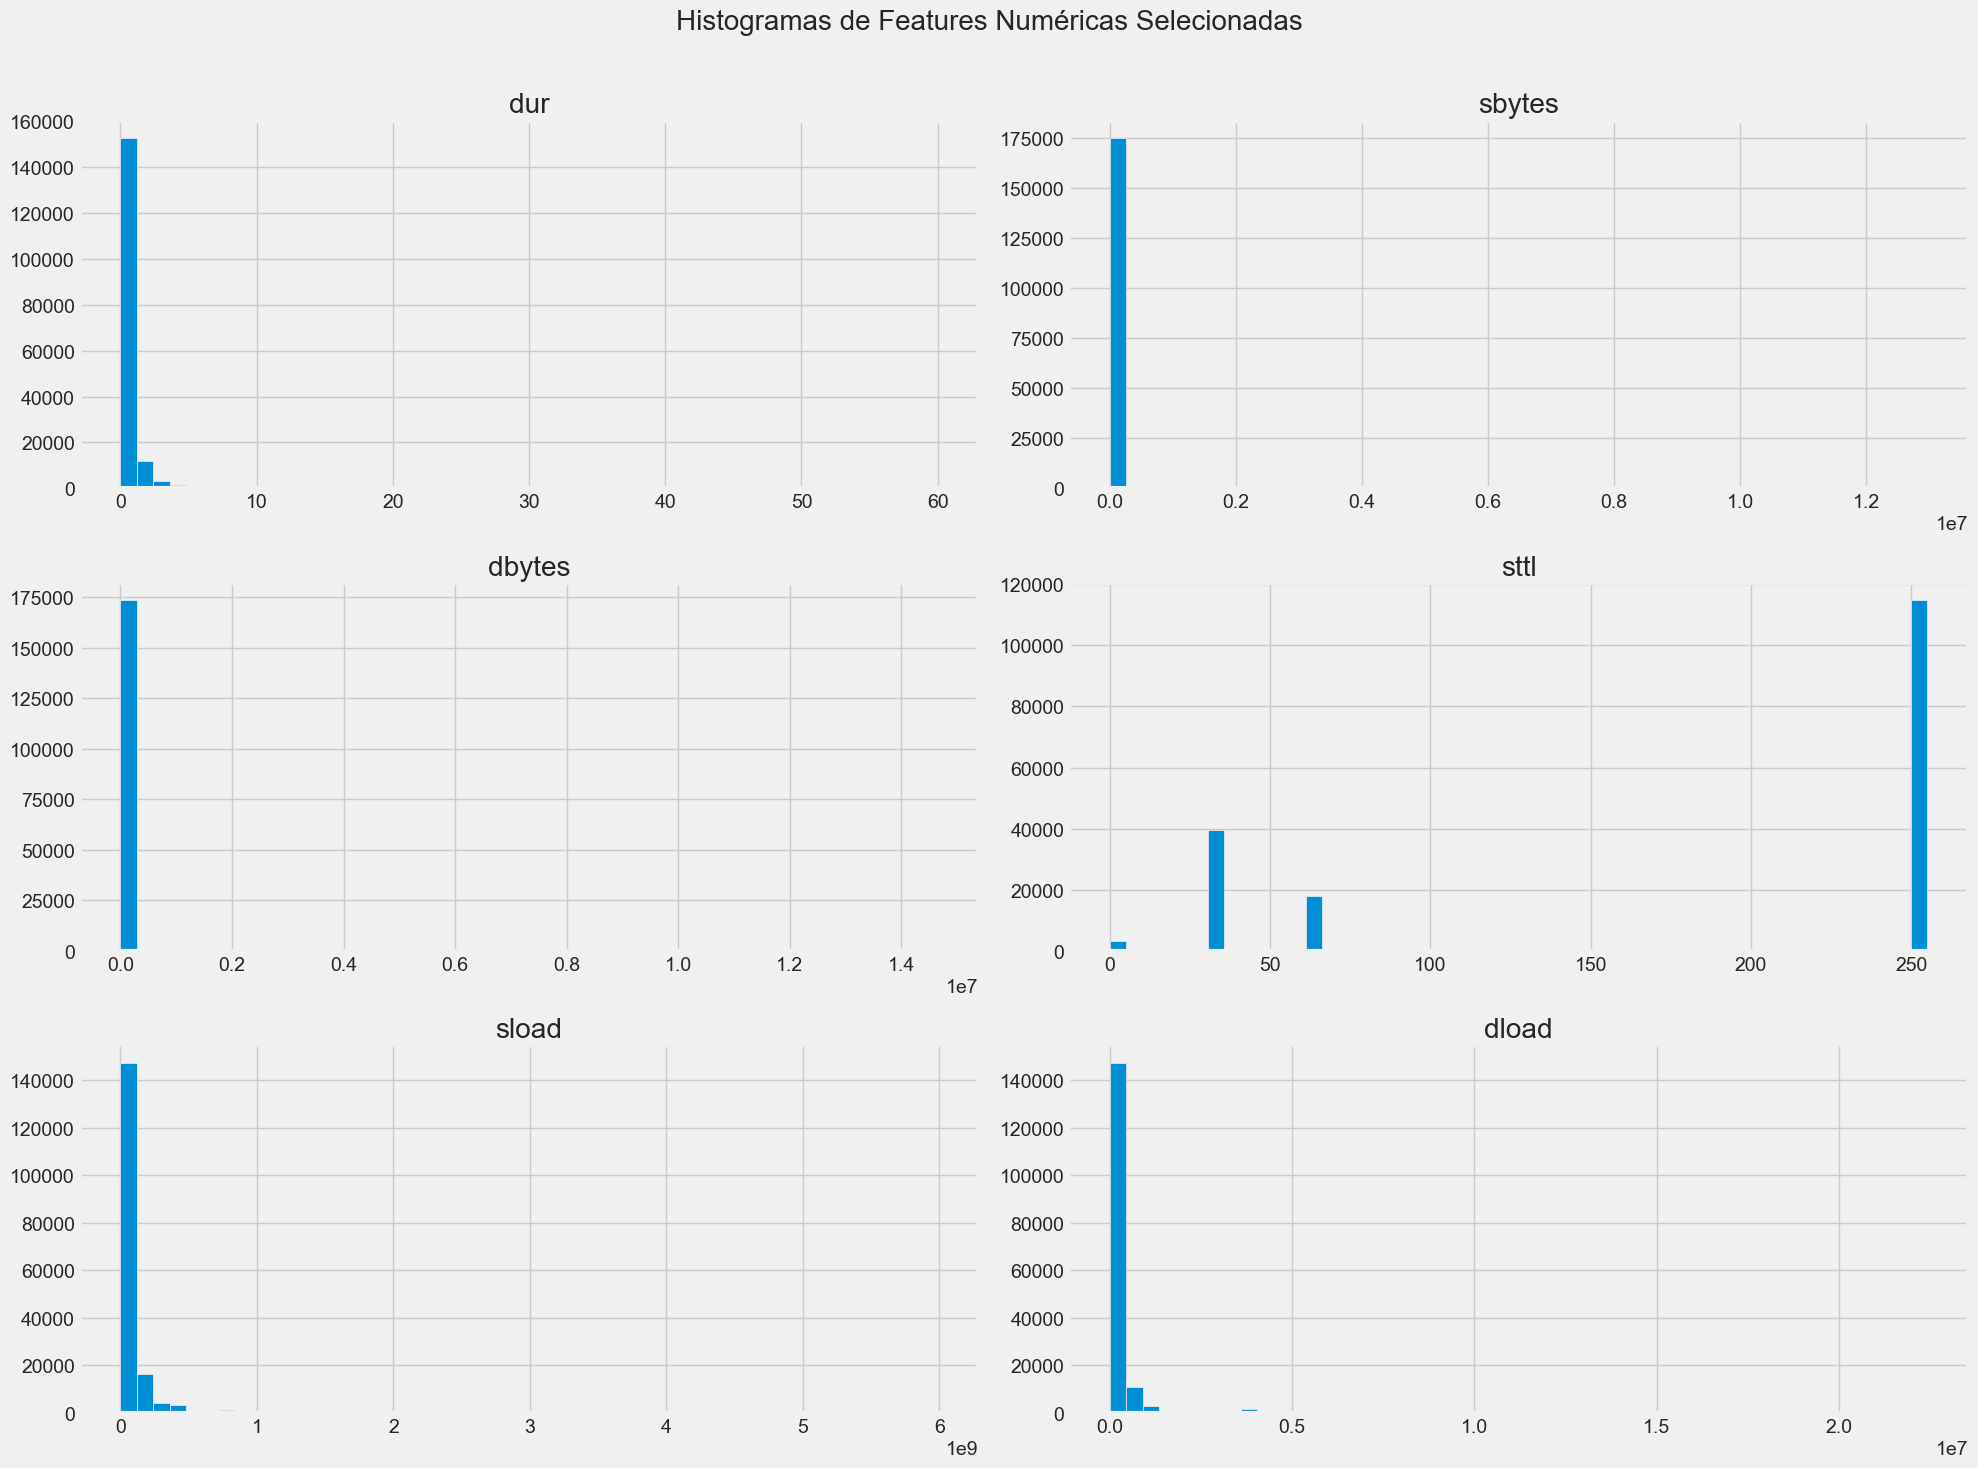

In [5]:
# Descrevendo as estatísticas das features numéricas
print("--- Estatísticas Descritivas (Features Numéricas) ---")
display(df_train.describe())

# Visualizando a distribuição de algumas features numéricas importantes
numeric_cols_to_plot = ['dur', 'sbytes', 'dbytes', 'sttl', 'sload', 'dload']
df_train[numeric_cols_to_plot].hist(bins=50, figsize=(20, 15))
plt.suptitle('Histogramas de Features Numéricas Selecionadas', size=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

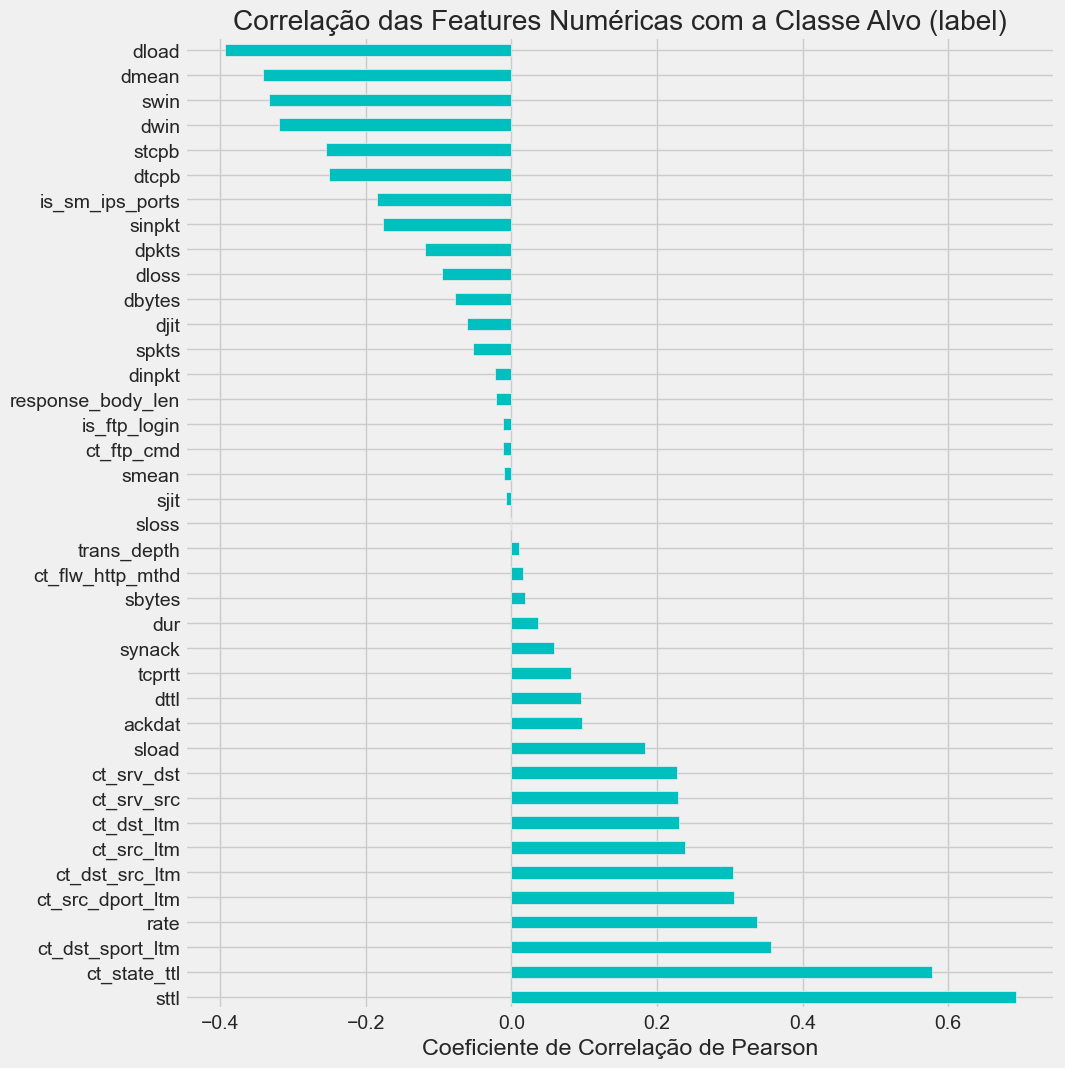

Top 10 features mais correlacionadas com 'label':
label               1.000000
sttl                0.692741
ct_state_ttl        0.577704
ct_dst_sport_ltm    0.357213
rate                0.337979
ct_src_dport_ltm    0.305579
ct_dst_src_ltm      0.303855
ct_src_ltm          0.238225
ct_dst_ltm          0.229887
ct_srv_src          0.229044
ct_srv_dst          0.228046
Name: label, dtype: float64


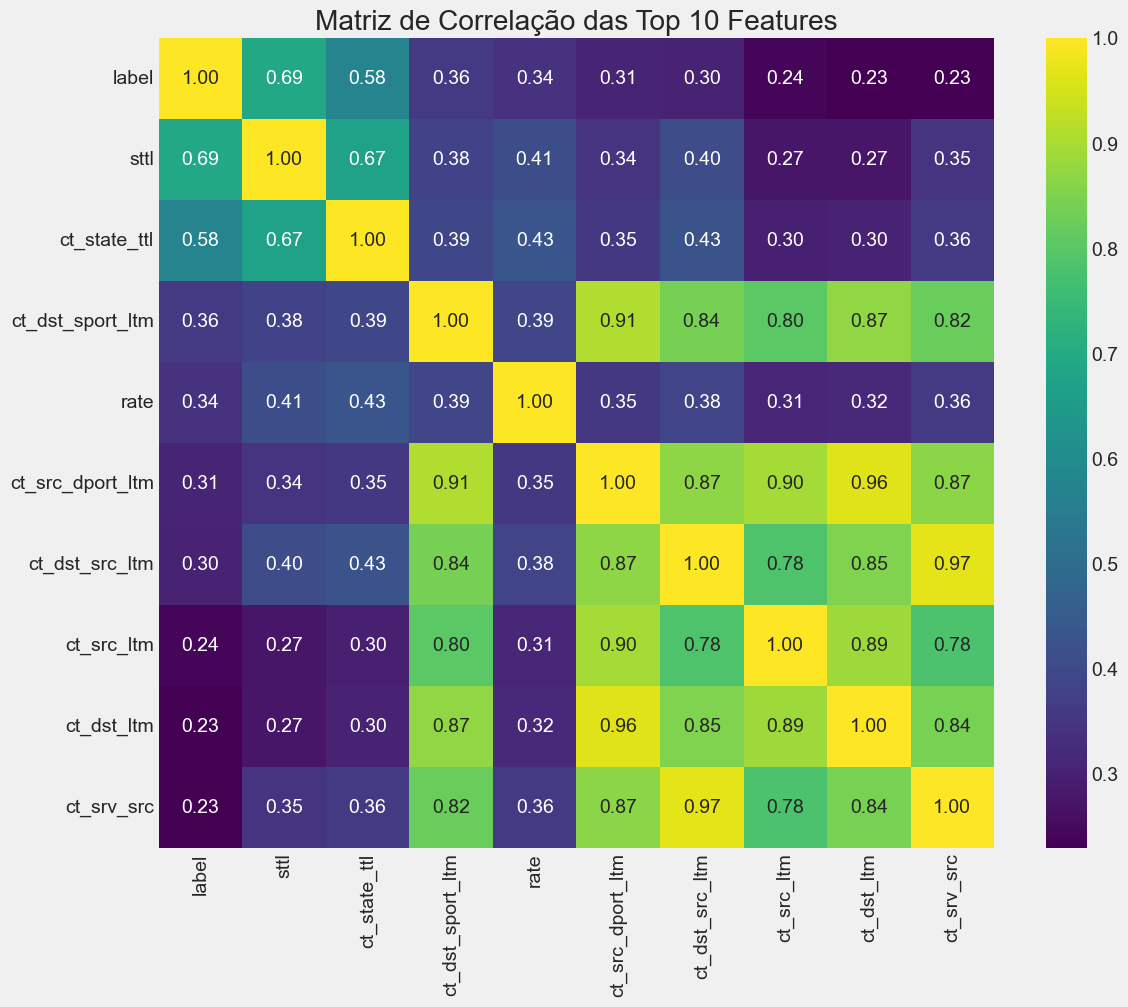

In [6]:
# Correlação das features numéricas com a variável alvo 'label'
# Excluindo 'id' e a própria 'label'
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('id')
if 'label' in numeric_cols:
    numeric_cols.remove('label')

corr_with_target = df_train[numeric_cols + ['label']].corr()['label'].sort_values(ascending=False)

plt.figure(figsize=(10, 12))
corr_with_target.drop('label').plot(kind='barh', color='c')
plt.title('Correlação das Features Numéricas com a Classe Alvo (label)')
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.show()

print("Top 10 features mais correlacionadas com 'label':")
print(corr_with_target.head(11))

# Matriz de correlação para um subconjunto das features mais correlacionadas
top_corr_features = corr_with_target.head(10).index.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Matriz de Correlação das Top 10 Features')
plt.show()

## Correlação por categoria de ataque (`attack_cat`)

Esta seção calcula e exibe a matriz de correlação (Pearson) entre as colunas **numéricas** para **cada ataque individual** presente em `attack_cat` (excluindo `Normal`/`Benign`, quando existirem).  
Além disso, salva os resultados (CSV + PNG) em uma pasta local para facilitar a consulta.


Colunas numéricas usadas na correlação: 39
Categorias de ataque encontradas: 9
Saída: C:\Users\GabrielMoreira\log-anomaly-detection-ml\notebooks\UNSW-NB15-Cybersecurity-Logs\correlations_by_attack_cat


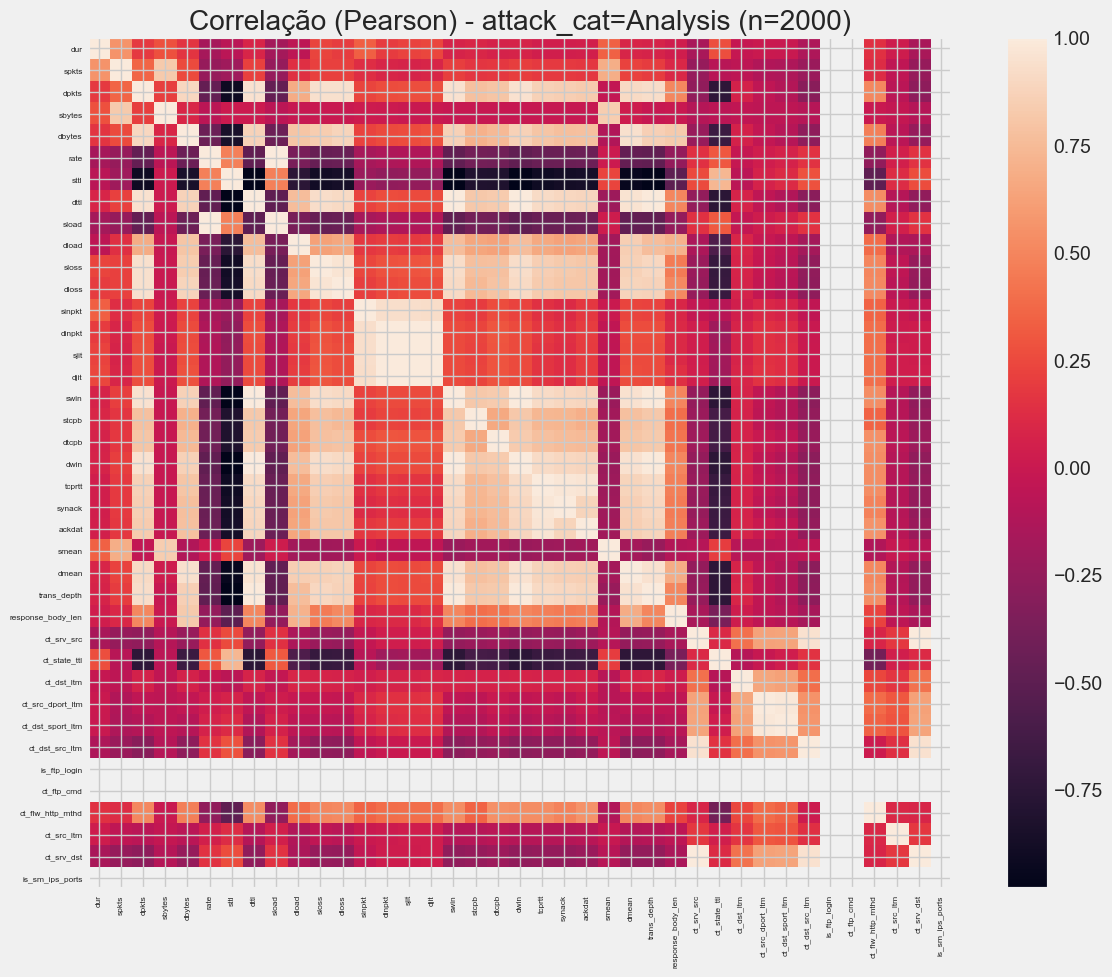

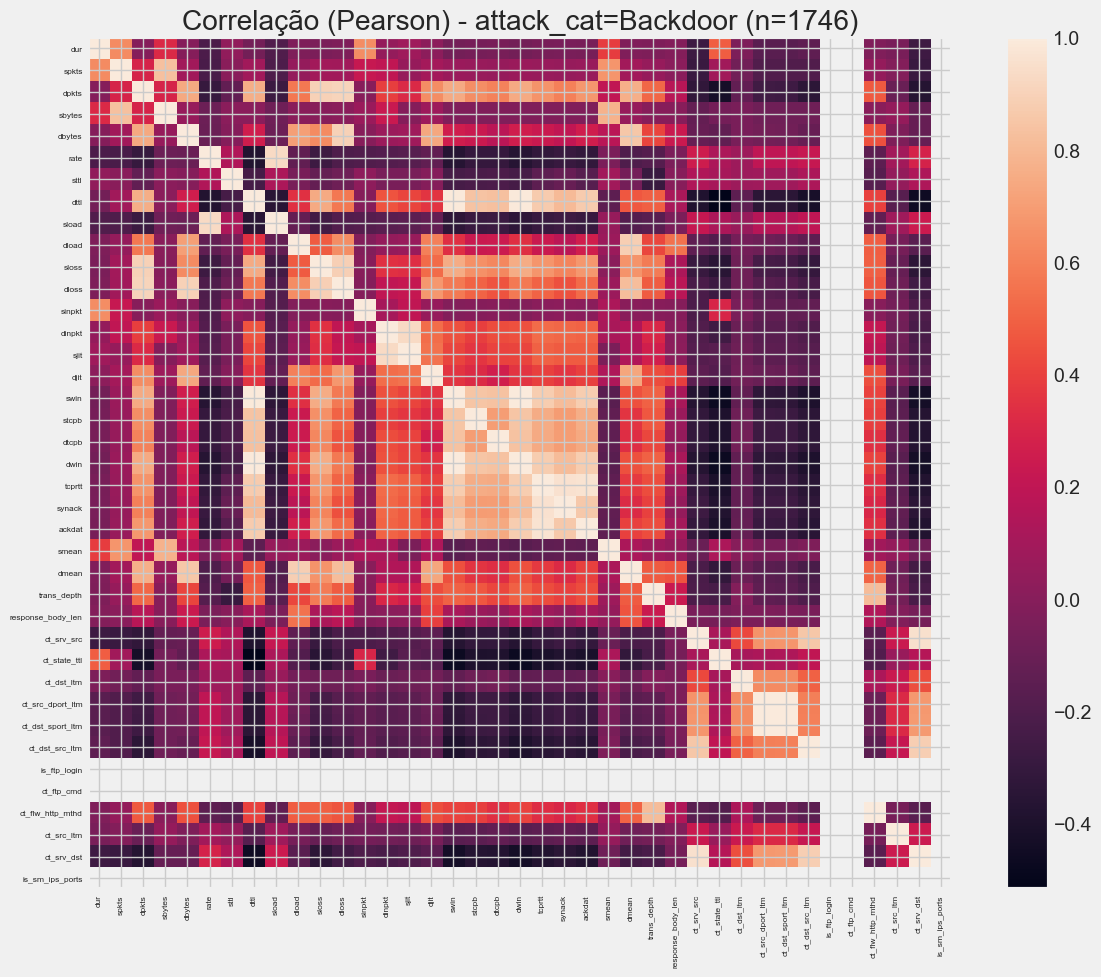

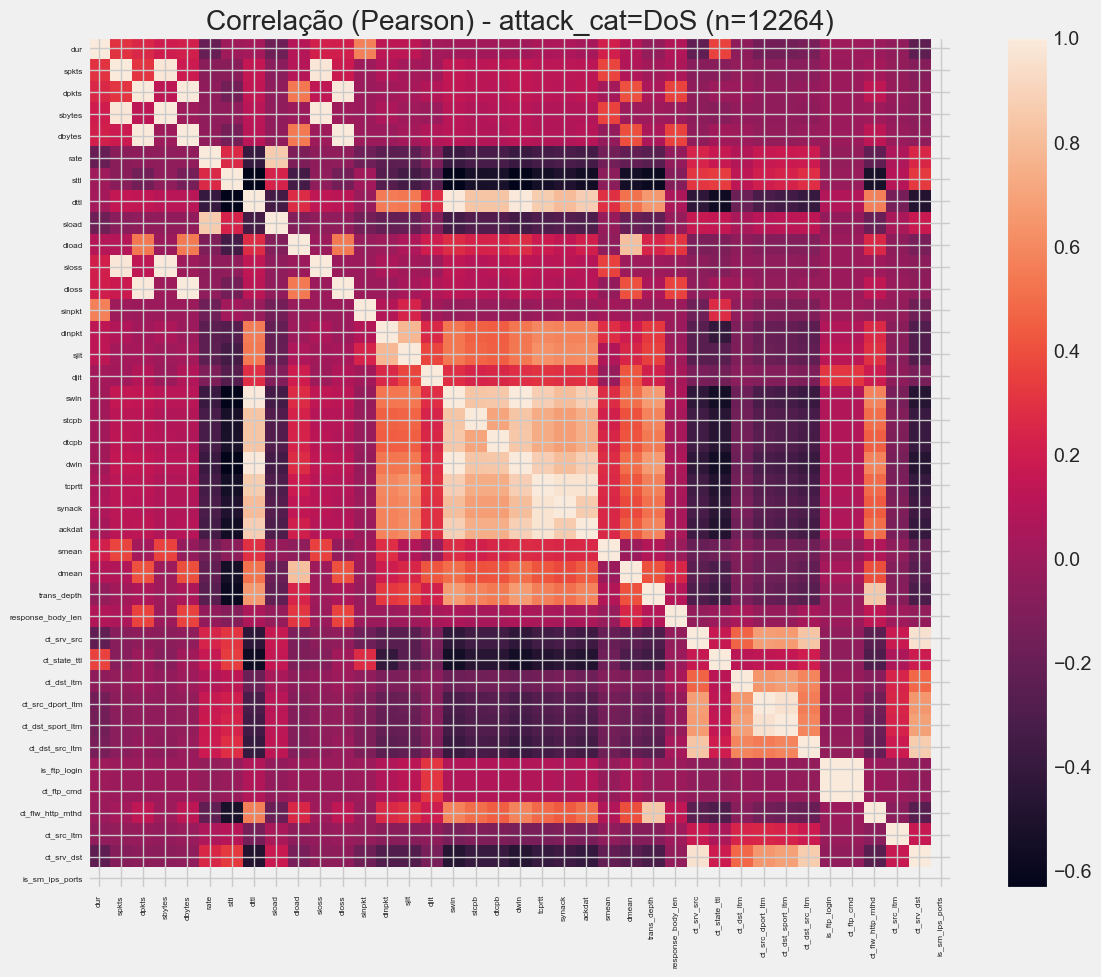

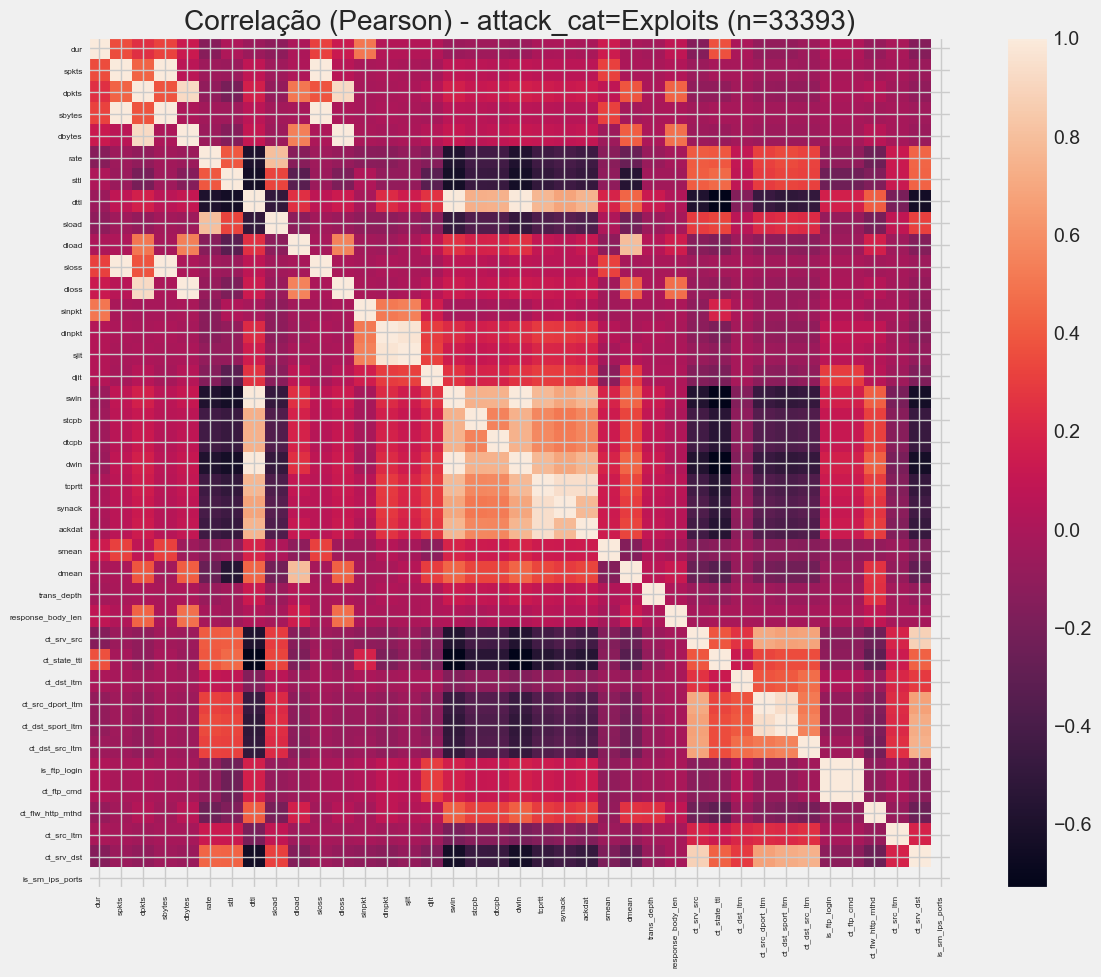

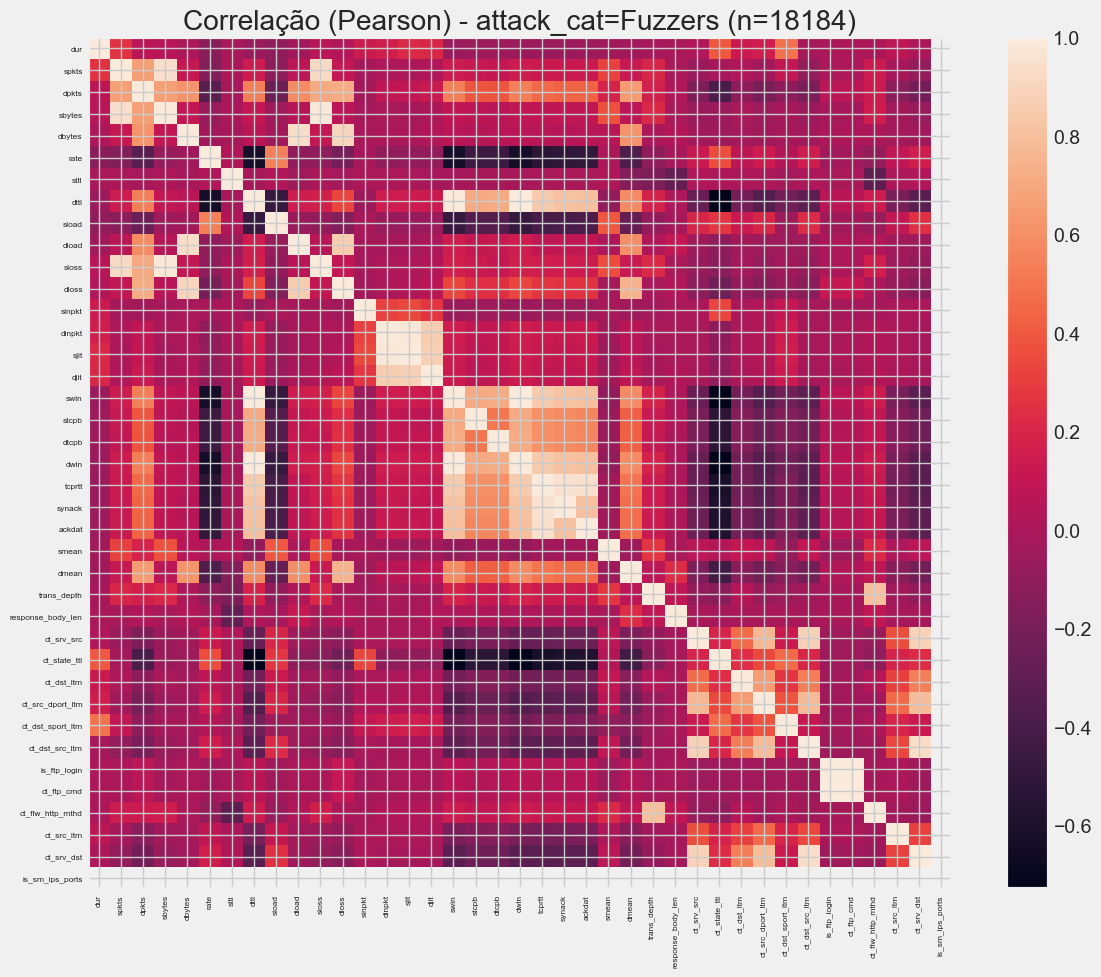

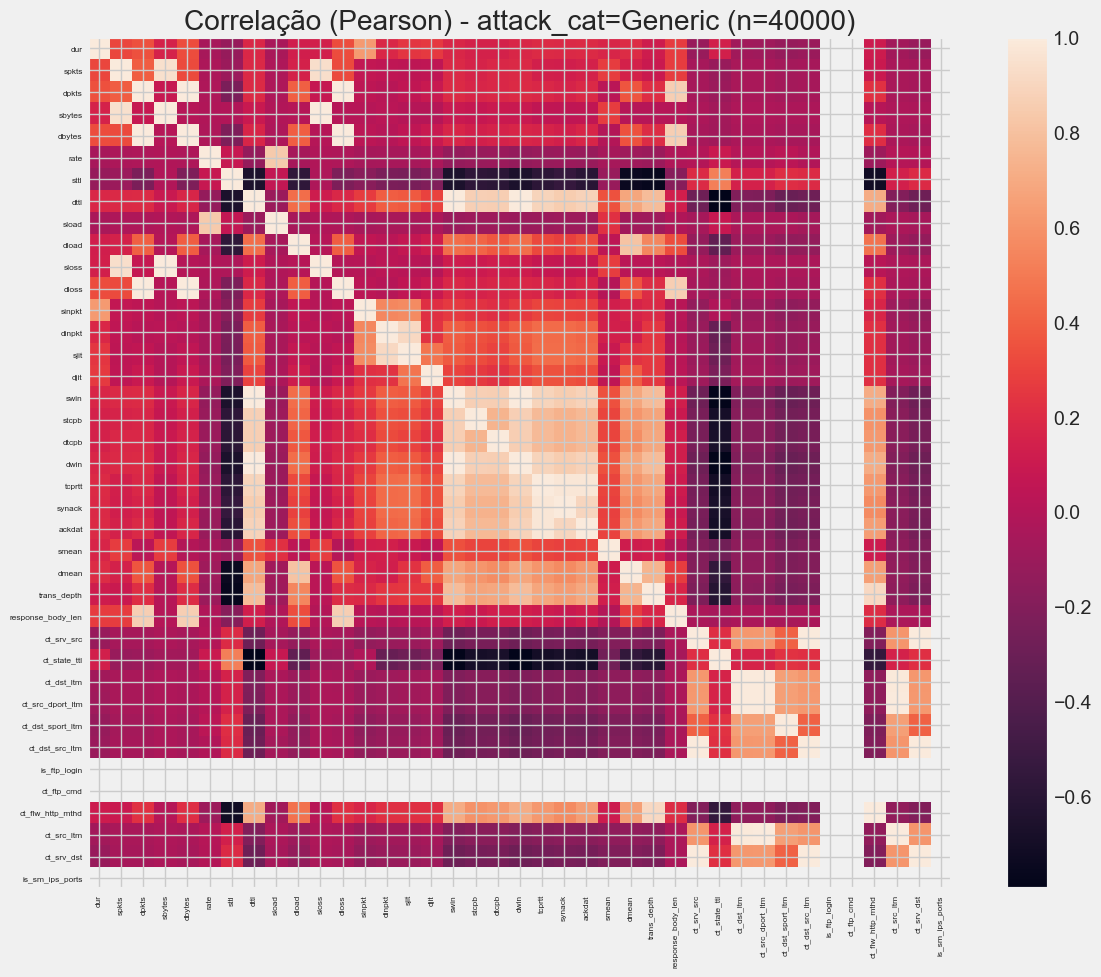

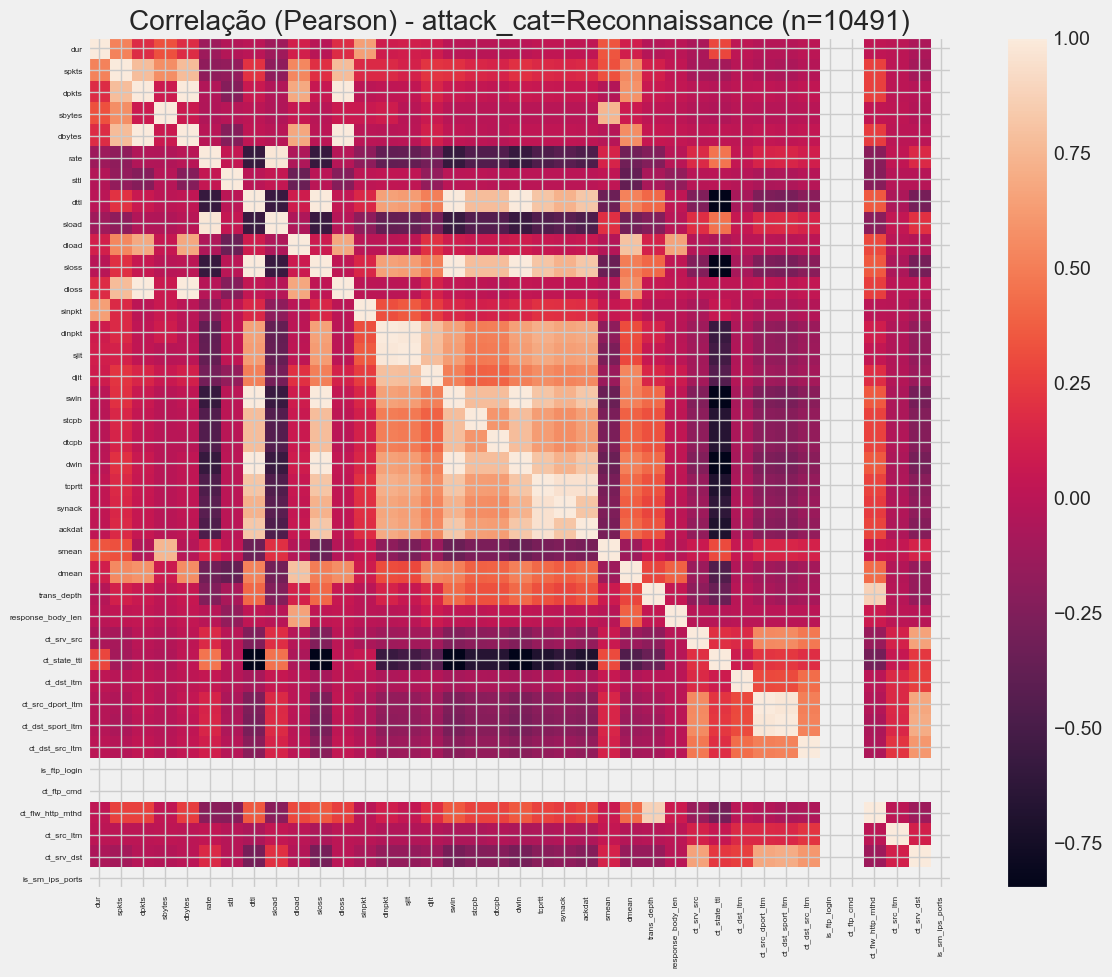

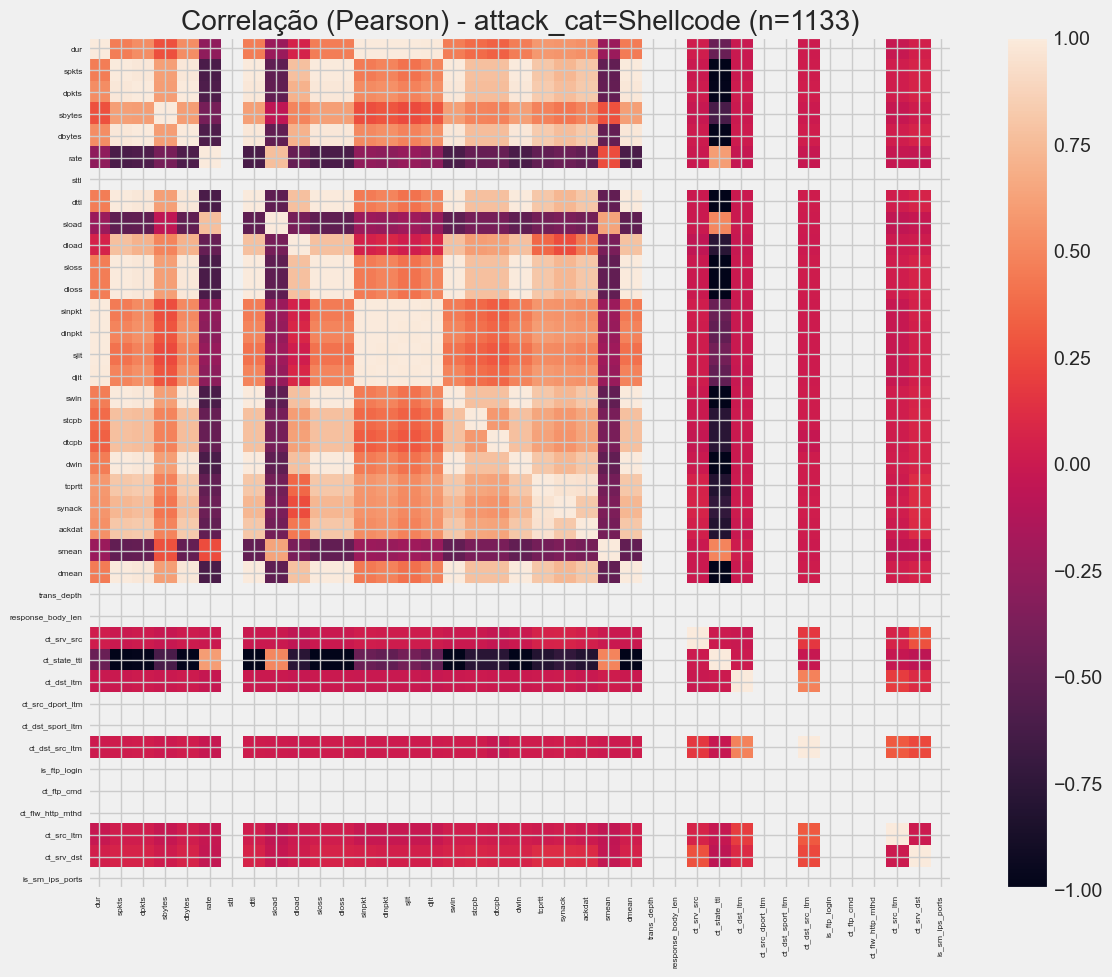

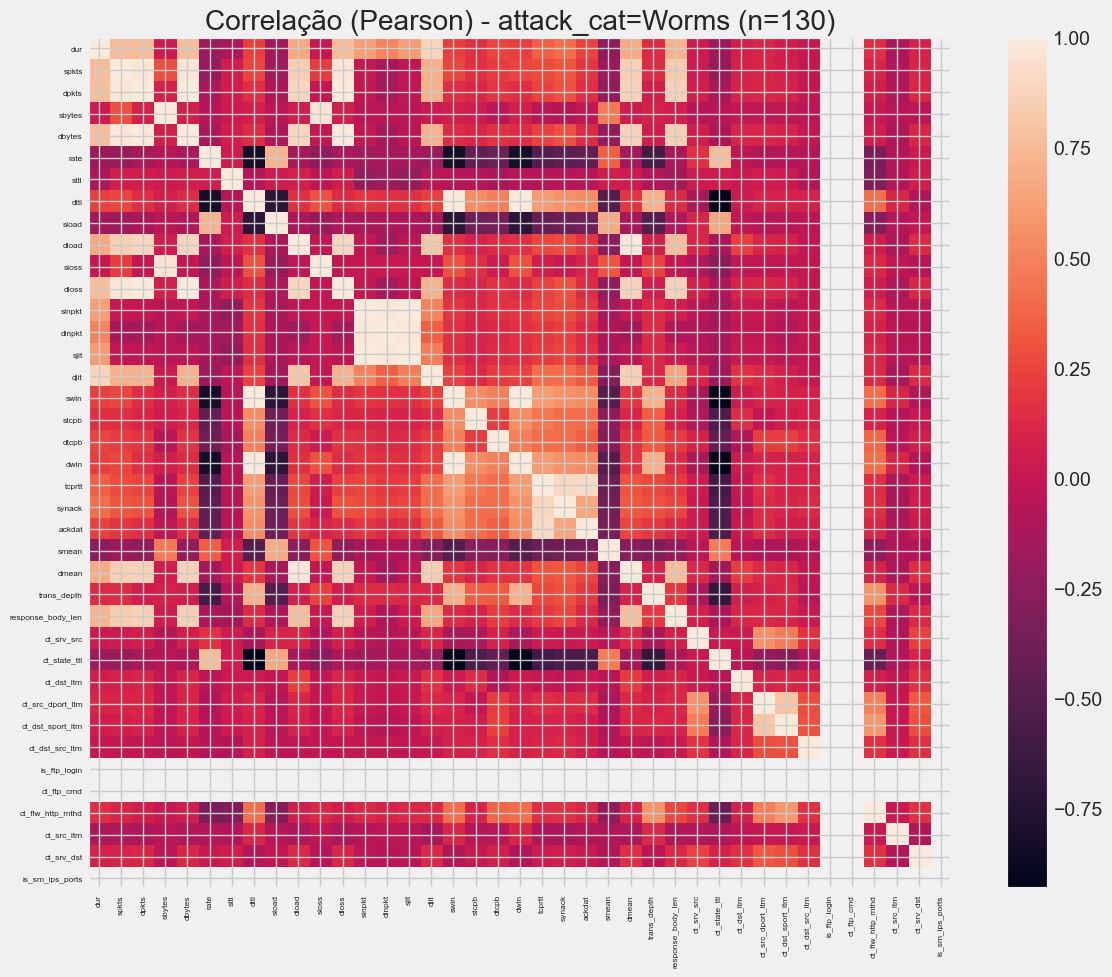

Concluído.


In [7]:
# === Correlação por categoria de ataque (attack_cat) ===
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use o dataset de treino como base (ajuste aqui se quiser usar outro dataframe)
df_base = df_train.copy()

if 'attack_cat' not in df_base.columns:
    raise KeyError("A coluna 'attack_cat' não foi encontrada em df_train. Verifique o carregamento do dataset.")

# Seleciona apenas colunas numéricas (evitando id/label)
numeric_cols = df_base.select_dtypes(include=[np.number]).columns.tolist()
for col_to_drop in ['id', 'label']:
    if col_to_drop in numeric_cols:
        numeric_cols.remove(col_to_drop)

if len(numeric_cols) < 2:
    raise ValueError("Não há colunas numéricas suficientes para calcular correlação.")

# Lista de ataques (exclui Normal/Benign se presentes)
attack_vals = []
for v in df_base['attack_cat'].dropna().unique().tolist():
    sv = str(v).strip()
    if sv.lower() in ['normal', 'benign']:
        continue
    attack_vals.append(v)

attack_vals = sorted(attack_vals, key=lambda x: str(x))

out_dir = "./correlations_by_attack_cat"
os.makedirs(out_dir, exist_ok=True)

print(f"Colunas numéricas usadas na correlação: {len(numeric_cols)}")
print(f"Categorias de ataque encontradas: {len(attack_vals)}")
print(f"Saída: {os.path.abspath(out_dir)}")

for attack in attack_vals:
    df_a = df_base[df_base['attack_cat'] == attack]
    n = len(df_a)
    if n < 2:
        print(f"[SKIP] attack_cat={attack} (n={n}) - amostras insuficientes")
        continue

    corr = df_a[numeric_cols].corr(method='pearson')

    # Salva CSV
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]+', '_', str(attack)).strip('_')
    csv_path = os.path.join(out_dir, f"corr_{safe_name}.csv")
    corr.to_csv(csv_path)

    # Plota matriz (heatmap simples com matplotlib)
    plt.figure(figsize=(12, 10))
    plt.imshow(corr, aspect='auto')
    plt.title(f"Correlação (Pearson) - attack_cat={attack} (n={n})")
    plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90, fontsize=6)
    plt.yticks(range(len(numeric_cols)), numeric_cols, fontsize=6)
    plt.colorbar()
    plt.tight_layout()

    png_path = os.path.join(out_dir, f"corr_{safe_name}.png")
    plt.savefig(png_path, dpi=200)
    plt.show()

print("Concluído.")
